# Illustrative notebook for pipeline 1: bacteria in circular chamber

written by: Nicolas Verschueren

contact: http://nverschueren.github.io


## Pipeline 1: Bacteria within the circular chamber

In what follows, we apply the Pipeline employed to detect and classify bacteria in the chamber to a representative image.



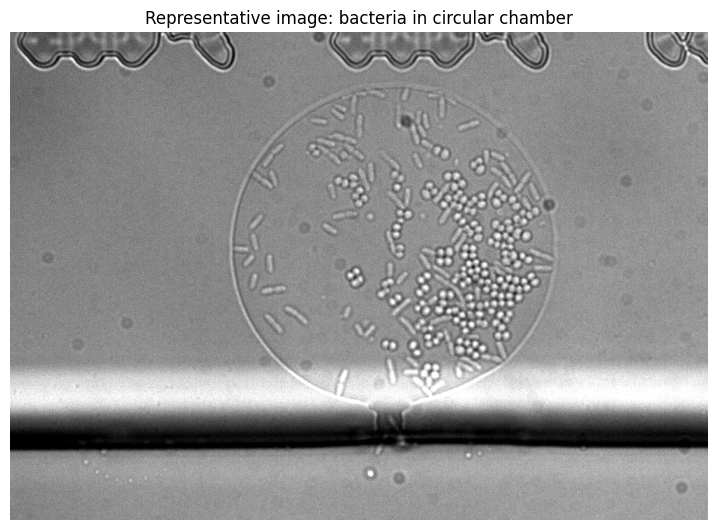

In [1]:
#Loading the representative image
import tifffile
import numpy as np
import matplotlib.pyplot as plt

img = tifffile.imread("example_low_res_circular_chamber.tif")

vmin, vmax = np.percentile(img, [1, 99])

plt.figure(figsize=(9, 9))
plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Representative image: bacteria in circular chamber")
plt.axis("off")
plt.show()

## Step 1: Preprocessing masking+CLAHE

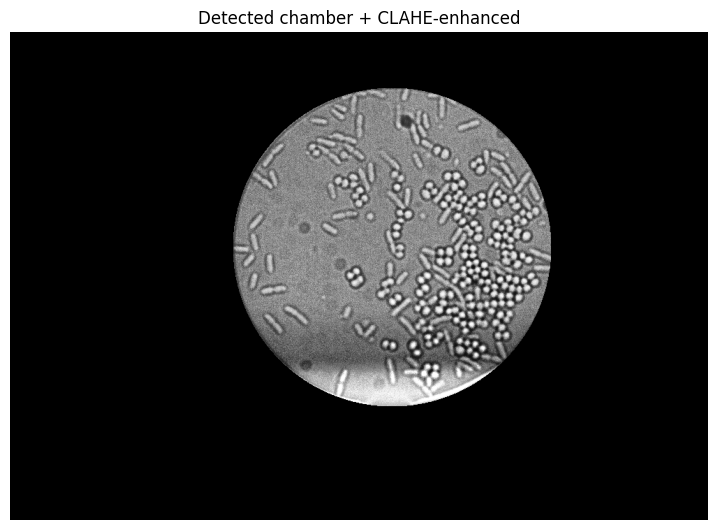

In [2]:
import cv2
import numpy as np
from skimage import exposure
from skimage.draw import disk


img_8bit = exposure.rescale_intensity(img.astype(float), out_range=(0, 255)).astype(np.uint8)
blurred = cv2.GaussianBlur(img_8bit, (9, 9), 2) #image is blurred  to make easier detect the circle

circles = cv2.HoughCircles(
    blurred, cv2.HOUGH_GRADIENT,
    dp=1.2, minDist=300, param1=60, param2=40,
    minRadius=150, maxRadius=400,
)#circle detection via Hough

cx, cy, r = np.round(circles[0][0]).astype(int)

mask = np.zeros(img_8bit.shape, dtype=bool)
rr, cc = disk((cy, cx), r, shape=img_8bit.shape)
mask[rr, cc] = True

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) #clahe processing on image
enhanced = clahe.apply(img_8bit)
enhanced[~mask] = 0

plt.figure(figsize=(9, 9))
plt.imshow(enhanced, cmap="gray")
plt.title("Detected chamber + CLAHE-enhanced")
plt.axis("off")
plt.show()

## Step 2: Segmentation (Detection) using CPSAM

This is the most computationally intensive step. If you don't have a GPU, it might take considerable time. To run the segmentation, uncomment the following cell. If you don't have the hardware for this, the expected labels have been provided and consequently the notebook can be run without this cell

In [8]:
# Uncomment to run CellPose-SAM live. Timed on this image (700x1000px, 304 cells)
# with cellpose 4.0.9: GPU 1.8s, CPU 474.8s (~8 min, ~260x slower) -- a GPU is
# strongly recommended. Runtime will vary by hardware and image size. By default
# this notebook uses the precomputed reference output loaded in the next cell.

# from cellpose import models
#
# model = models.CellposeModel(gpu=True)
# masks_live, flows, styles = model.eval(
#     enhanced, diameter=30, flow_threshold=0.4, cellprob_threshold=-1.0,
# )
# print(f"{masks_live.max()} cells detected")
# np.save("example_low_res_labels.npy", masks_live)

292 cells detected


This is what you should get (precomputed on GPU, for reference if running on a slow/CPU-only machine):

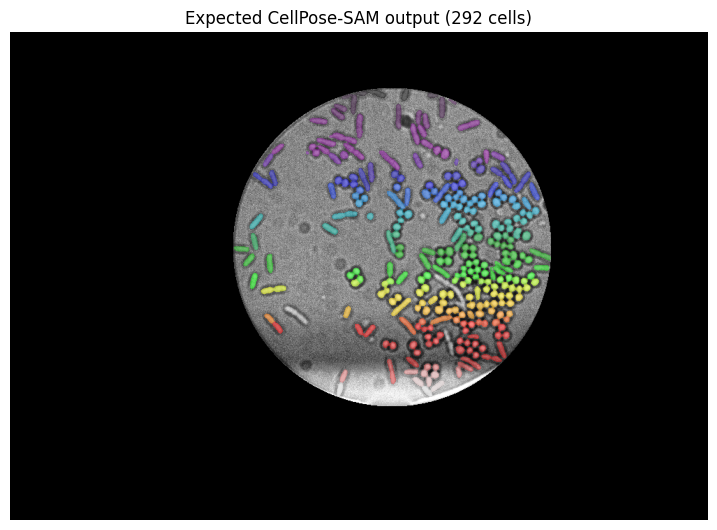

In [3]:
import matplotlib.pyplot as plt

masks_expected = np.load("example_low_res_labels_expected.npy")

plt.figure(figsize=(9, 9))
plt.imshow(enhanced, cmap="gray")
plt.imshow(np.ma.masked_where(masks_expected == 0, masks_expected), cmap="nipy_spectral", alpha=0.5)
plt.title(f"Expected CellPose-SAM output ({masks_expected.max()} cells)")
plt.axis("off")
plt.show()

# use the live result if the cell above was uncommented and run, otherwise fall back
# to the precomputed reference -- everything below just uses 'masks'
masks = masks_live if "masks_live" in dir() else masks_expected
#the detections correspond to a label matrix, that's why the different colors

## Step3: Classification into cocci and bacilli (circularity + area, split via watershed)

Computing the circularity and area of each mask, we observe a bimodal distribution where each population correspond to a type of bacteria. The watershed algorithm is used to discover the frontier between them

In [4]:
# measure every detected cell with cv2 contours (contourArea/arcLength) --

measurements = []
for cell_id in range(1, int(masks.max()) + 1):
    cell_bin = (masks == cell_id).astype(np.uint8)
    contours, _ = cv2.findContours(cell_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        continue
    cnt = contours[0]
    area = float(cv2.contourArea(cnt))
    perimeter = float(cv2.arcLength(cnt, True))
    if perimeter == 0 or area < 5:
        continue
    circularity = round((4 * np.pi * area) / (perimeter ** 2), 4)
    measurements.append(dict(label=cell_id, area=area, circularity=circularity))

print(f"{len(measurements)} cells measured")

292 cells measured


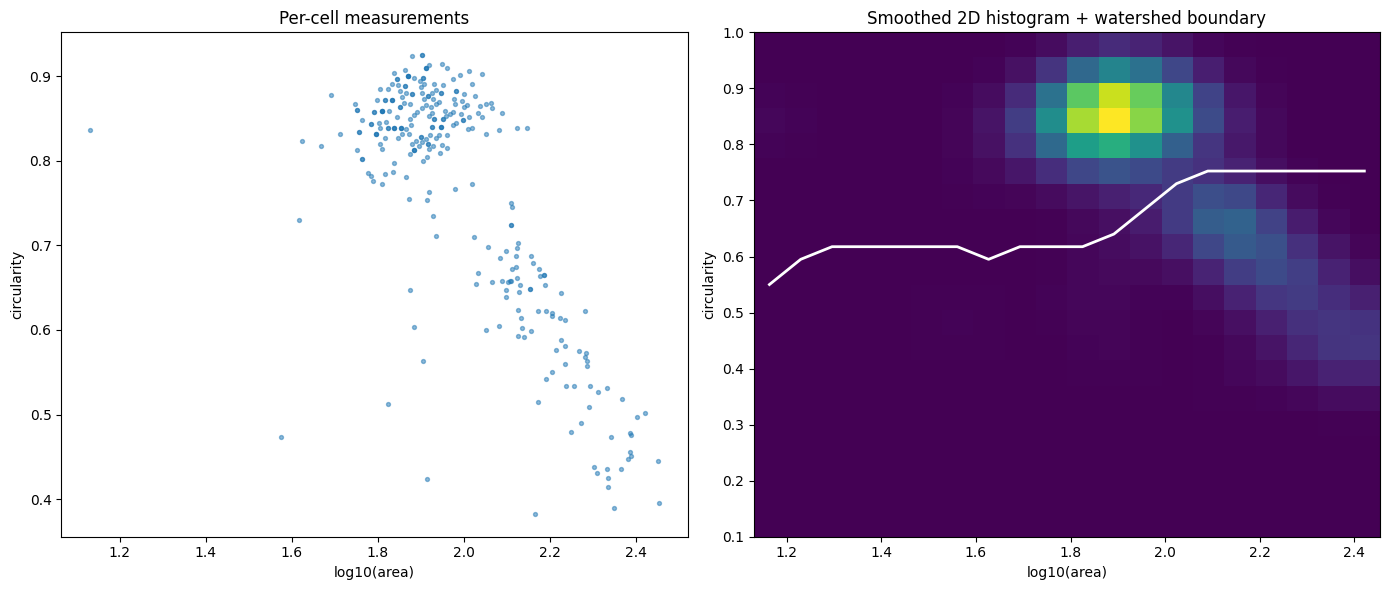

In [5]:
# derive the cocci/bacilli split directly from this image's own cells: a 2D
# histogram of log10(area) vs. circularity should show two populations (round,
# high circularity vs. elongated, lower circularity); watershed on the smoothed
# histogram finds the ridge between them. This is computed here, from data
# already in this notebook -- not loaded from an external pre-fit file.
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

areas = np.array([m["area"] for m in measurements])
circs = np.array([m["circularity"] for m in measurements])
log_a = np.log10(np.clip(areas, 1, None))

n_bins = 20
H, xedges, yedges = np.histogram2d(
    log_a, circs, bins=n_bins, range=[[log_a.min(), log_a.max()], [0.1, 1.0]]
)
H_smooth = gaussian_filter(H, sigma=1.0)
peaks = peak_local_max(H_smooth, num_peaks=2, min_distance=2)

markers = np.zeros_like(H, dtype=int)
markers[peaks[0, 0], peaks[0, 1]] = 1
markers[peaks[1, 0], peaks[1, 1]] = 2
ws_labels = watershed(-H_smooth, markers)

# per log-area bin, the circularity value of the ridge between the two populations
xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
boundary = np.zeros_like(H, dtype=bool)
boundary[:-1, :] |= ws_labels[:-1, :] != ws_labels[1:, :]
boundary[:, :-1] |= ws_labels[:, :-1] != ws_labels[:, 1:]
bnd_i, bnd_j = np.where(boundary)

boundary_lookup = {}
for i in range(n_bins):
    m = bnd_i == i
    if m.sum() > 0:
        boundary_lookup[i] = float(np.median(yc[bnd_j[m]]))
filled = sorted(boundary_lookup.keys())
all_thresholds = np.interp(np.arange(n_bins), filled, [boundary_lookup[b] for b in filled])
boundary_lookup = {i: float(all_thresholds[i]) for i in range(n_bins)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(log_a, circs, s=8, alpha=0.5)
axes[0].set_xlabel("log10(area)"); axes[0].set_ylabel("circularity")
axes[0].set_title("Per-cell measurements")
axes[1].imshow(H_smooth.T, origin="lower", aspect="auto",
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
axes[1].plot(xc, [boundary_lookup[i] for i in range(n_bins)], color="white", linewidth=2)
axes[1].set_xlabel("log10(area)"); axes[1].set_ylabel("circularity")
axes[1].set_title("Smoothed 2D histogram + watershed boundary")
plt.tight_layout()
plt.show()

In [6]:
def classify_cell(area, circularity):
    log_a = np.log10(max(area, 1))
    bin_i = int(np.clip(np.searchsorted(xedges[1:], log_a), 0, n_bins - 1))
    return "cocci" if circularity >= boundary_lookup[bin_i] else "bacilli"

records = []
for m in measurements:
    shape = classify_cell(m["area"], m["circularity"])
    records.append(dict(m, shape=shape))

for r in records[:5]:
    print(r)

{'label': 1, 'area': 128.5, 'circularity': 0.7244, 'shape': 'bacilli'}
{'label': 2, 'area': 178.0, 'circularity': 0.4797, 'shape': 'bacilli'}
{'label': 3, 'area': 80.5, 'circularity': 0.5631, 'shape': 'bacilli'}
{'label': 4, 'area': 75.0, 'circularity': 0.6478, 'shape': 'cocci'}
{'label': 5, 'area': 66.5, 'circularity': 0.5124, 'shape': 'bacilli'}


## Result: Detection+classification  over raw image

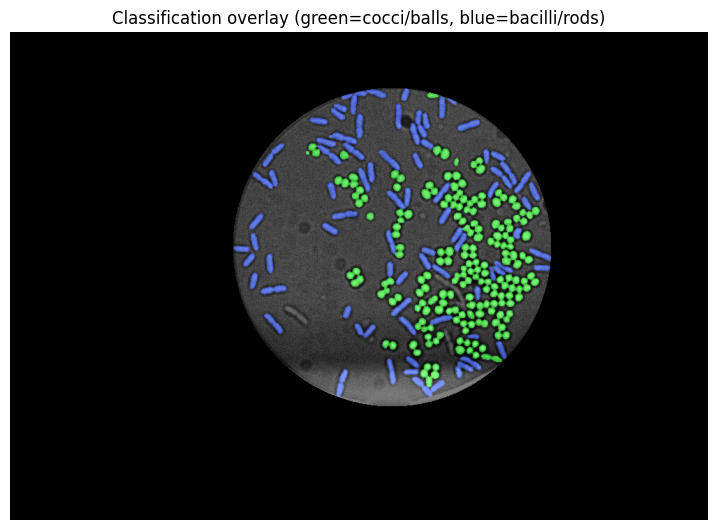

In [7]:
COLOR = {"cocci": (0.0, 1.0, 0.0), "bacilli": (0.0, 0.2, 1.0)}

overlay = np.zeros((*masks.shape, 3))
for r in records:
    color = COLOR[r["shape"]]
    for c in range(3):
        overlay[:, :, c] += (masks == r["label"]) * color[c]

plt.figure(figsize=(9, 9))
plt.imshow(enhanced, cmap="gray")
plt.imshow(overlay, alpha=0.5)
plt.title("Classification overlay (green=cocci/balls, blue=bacilli/rods)")
plt.axis("off")
plt.show()

## Data extraction:
From the classified bacteria, we can extract any desired measurement. A simple computation is the total number of each bacteria

In [8]:
import pandas as pd
from collections import Counter

counts = Counter(r["shape"] for r in records)
summary = pd.DataFrame({"detection": list(counts.keys()), "number": list(counts.values())})
summary

,detection,number
0,bacilli,94
1,cocci,198


## Final comment:
In this example most of the bacteria was detected via CpSAm. The classification provide a very good result. In pracitce, the labels can be amended a posteriori, using napari or similar labelling software. Our own version of relabelling is available upon request.